In [1]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

In [2]:
api = wandb.Api()

In [4]:
ACCURACY_CACHE = dict()

def get_accuracy(arch, dataset):
    
    
    key = f"{arch}-{dataset}"

    if key in ACCURACY_CACHE:
        return ACCURACY_CACHE[key]
    
    
    model = models.get_model(arch)
    ds = datasets.construct(dataset)
    
    ds_val = ds.create_subset(train_split=False)
    
    val_dl = DataLoader(ds_val, batch_size=128, shuffle=False)
    
    acc = metrics.accuracy_with_subclasses(
        model, 
        val_dl,
        ds.selected_classes,
        ds.transform_target,
        device="cpu"
    )
    
    ACCURACY_CACHE[key] = acc
    
    return get_accuracy(arch, dataset)
    
teacher_acc = get_accuracy("cifar100-resnet18-p1", "cifar100-people")
teacher_acc

We are building `cifar100-people` containing 5 fine classes
> baby (2)
> boy (11)
> girl (35)
> man (46)
> woman (98)


Computing accuracy for selected claseses: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:02<00:00,  1.42it/s]


(0.550000011920929, 1.6981168985366821)

In [8]:
def load_history(run):

    
    data = []

    
    attrs = dict()
    for k in [
        "basis_name", "seed", "compression_ratio", "approximator",
        "approximator_mode", "lambda_mse", "lambda_xent", "dataset", "layer", "teacher_model",
        "training_size",
    ]:
        attrs[k] = run.config[k]
  
    history = run.scan_history(keys=["val_acc", "epoch"])

    for ix, row in enumerate(history):

        new_row = dict(**attrs)

        for k in ["val_acc", "epoch"]:
            new_row[k] = row[k]

        data.append(new_row)
        
    return data

def read_data(
    dataset,
    teacher_model,
    layer,
):
    
    
    runs = api.runs('p16i/kitchen-sink')
    
    return runs[0].summary
#     {
#         "$and": [
#             {"group": "./artifacts/2023-08-s10/experiments/distillation-for-meeting"},
#             {"config.dataset": dataset},
#             {"config.layer": layer},
#             {"config.teacher_model": teacher_model},
#         ]
#     })
    
#     print(f"We have {len(runs)} runs")
    
#     rows = []
    
#     for runs in tqdm(runs):
#         rows.extend(load_history(runs))
        
#     return pd.DataFrame(rows)


summary = read_data(
    dataset="cifar100-people",
    teacher_model="cifar100-resnet18-p1",
    layer='layer3',
)

In [10]:
summary["arr_metrics"]

{'val': [0.2109375, 0.23399999737739563, 0.23800000548362732, 0.2540000081062317, 0.2540000081062317, 0.2840000092983246], 'train': [0.2240000069141388, 0.20000000298023224, 0.2240000069141388, 0.2680000066757202, 0.2680000066757202]}

In [11]:
raise

RuntimeError: No active exception to reraise

In [8]:
# df_people_cifar100.to_csv("cifar100-resnet18-p1--cifar100-people.csv")
df_people_cifar100 = pd.read_csv("cifar100-resnet18-p1--cifar100-people.csv")

In [9]:
df_people_cifar100[:2]

,Unnamed: 0,basis_name,seed,compression_ratio,approximator,approximator_mode,lambda_mse,lambda_xent,dataset,layer,teacher_model,training_size,val_acc,epoch
0,0,identity--centered,3,8,homogenous_lowrank_adapter-identity--centered-...,homogenous_lowrank_adapter,1,1,cifar100-people,layer3,cifar100-resnet18-p1,1.0,0.258,0
1,1,identity--centered,3,8,homogenous_lowrank_adapter-identity--centered-...,homogenous_lowrank_adapter,1,1,cifar100-people,layer3,cifar100-resnet18-p1,1.0,0.356,1


In [10]:
def marker(basis_name):
    if basis_name in ["prca-abs", "prca-recon"]:
        return "|"
    if "pcaprca" in basis_name:
        return "."
    else:
        return ""
    
def label(approximator):
    short_approx_mode = approximator\
        .replace("genous", "") \
        .replace("lowrank", "lr") \
        .replace("centered", "")
    
    
    return short_approx_mode.split("--")[0]    
    
def ls(basis_name):
    if "identity" in basis_name  :
        return "--"
    elif "random" in basis_name:
        return ":"
    else:
        return "-"

We have 9000 rows for `training_size=1.0` and `compression_ratio=8`
We have 6 approximators


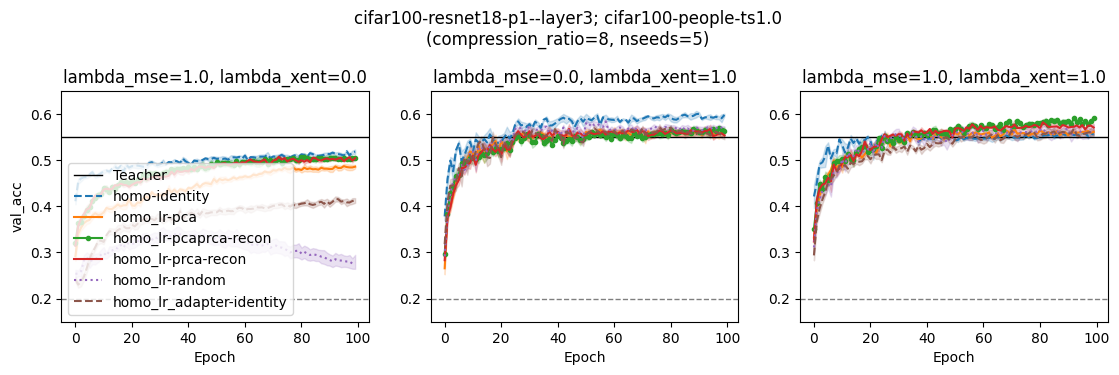

In [11]:
def viz(
    df_main, 
    teacher_model, 
    dataset, 
    layer, 
    training_size, 
    compression_ratio,
    arr_lambda_mse_xent = [
        (1.0, 0.0),
        (0.0, 1.0),
        (1.0, 1.0)
    ],
    show_legend=True
):
    
    expected_nseeds=  5
    
    df = df_main[
        (df_main["training_size"] == training_size)
        & (df_main["compression_ratio"].isin([1., compression_ratio]))
        & (df_main["teacher_model"] == teacher_model)
        & (df_main["layer"] == layer)
        & (df_main["dataset"] == dataset)
    ]
    
    print(f"We have {df.shape[0]} rows for `training_size={training_size}` and `compression_ratio={compression_ratio}`")
    
    approximators = sorted(df["approximator"].unique())
    
    
    print(f"We have {len(approximators)} approximators")
    

    ncols = len(arr_lambda_mse_xent)
    
    plt.figure(figsize=(4.5*ncols, 3))
    
    plt.suptitle("\n".join([
      f"{teacher_model}--{layer}; {dataset}-ts{training_size}",
      f"(compression_ratio={compression_ratio}, nseeds={expected_nseeds})"
    ]), y=1.15)
    
    
    teacher_acc, _ = get_accuracy(teacher_model, dataset)
    
    vmax = teacher_acc + 0.1
    vmin = 0.15
    
    for idx, (lambda_mse, lambda_xent) in enumerate(arr_lambda_mse_xent):
        plt.subplot(1, ncols, idx+1)
        plt.axhline(teacher_acc, ls="-", color="black", lw=1, label="Teacher")       
        plt.axhline(0.2, ls="--", color="black", alpha=0.5, lw=1)

        
        plt.title(f"lambda_mse={lambda_mse}, lambda_xent={lambda_xent}")

        for approximator in approximators:
            df_approx = df[
                (df["lambda_mse"] == lambda_mse) 
                & (df["lambda_xent"] == lambda_xent) 
                & (df["approximator"] == approximator) 
            ]
            
            df_approx = df_approx.groupby(by="epoch").agg(
                {"val_acc": ["mean", "std"], "seed": ["count"]}
            ).reset_index()
            
            np.testing.assert_allclose(df_approx["seed"]["count"], expected_nseeds)
            
            epochs = df_approx["epoch"]
            mean = df_approx["val_acc"]["mean"]
            stderr = df_approx["val_acc"]["std"] / (expected_nseeds ** 0.5)
            
            plt.plot(
                epochs,
                mean,
                label=label(approximator),
                ls=ls(approximator),
                marker=marker(approximator)
            )
            
            plt.fill_between(
                epochs,
                mean-stderr,
                mean+stderr,
                color=plt.gca().lines[-1].get_color(),
                alpha=0.2
            )
            
            plt.xlabel("Epoch")
            plt.ylim([vmin, vmax])
            
            
        if idx == 0:
            plt.ylabel("val_acc")
            
            if show_legend:
                plt.legend(loc="lower left")
        
viz(
    df_people_cifar100,
    training_size=1.0, 
    compression_ratio=8,
    teacher_model="cifar100-resnet18-p1",
    layer="layer3",
    dataset="cifar100-people"
)

# Comparision of MSE Distillation Across Different Trianing Sizes

We have 9000 rows for `training_size=1.0` and `compression_ratio=8`
We have 6 approximators
We have 9000 rows for `training_size=0.25` and `compression_ratio=8`
We have 6 approximators
We have 9000 rows for `training_size=0.1` and `compression_ratio=8`
We have 6 approximators


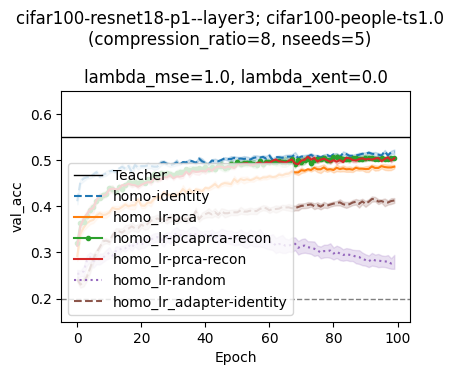

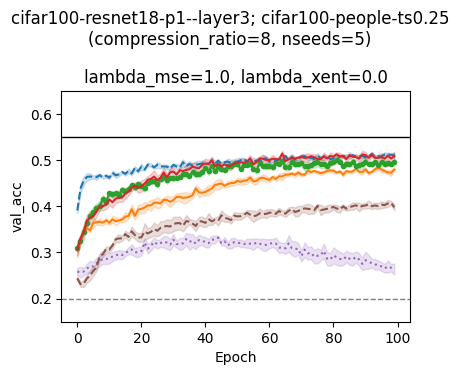

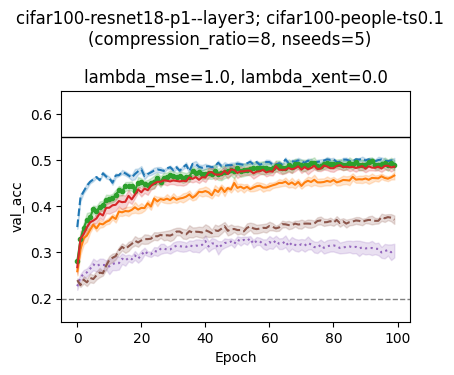

In [12]:
for ix, training_size in enumerate([1.0, 0.25, 0.1]):
    viz(
        df_people_cifar100,
        training_size=training_size, 
        compression_ratio=8,
        teacher_model="cifar100-resnet18-p1",
        layer="layer3",
        dataset="cifar100-people",
        arr_lambda_mse_xent=[(1.0, 0.0)],
        show_legend=ix==0
    )

# Comparison of Distillation with Combination of MSE and Xent

We have 9000 rows for `training_size=1.0` and `compression_ratio=8`
We have 6 approximators
We have 9000 rows for `training_size=0.25` and `compression_ratio=8`
We have 6 approximators
We have 9000 rows for `training_size=0.1` and `compression_ratio=8`
We have 6 approximators


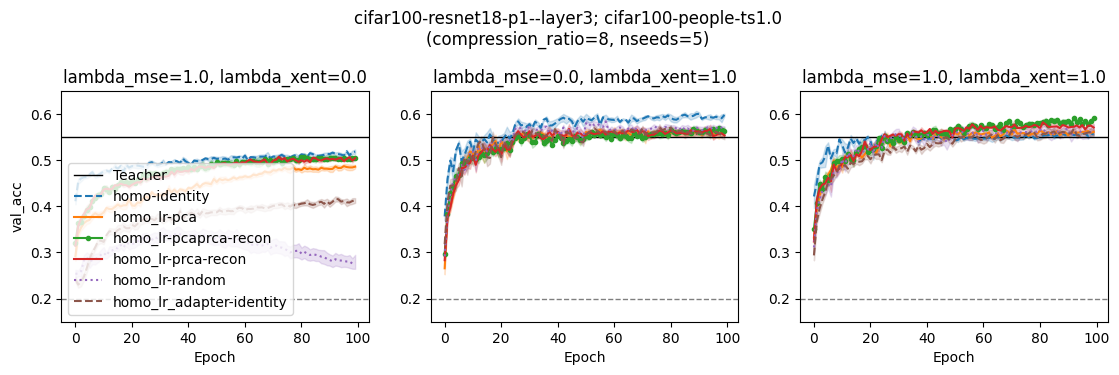

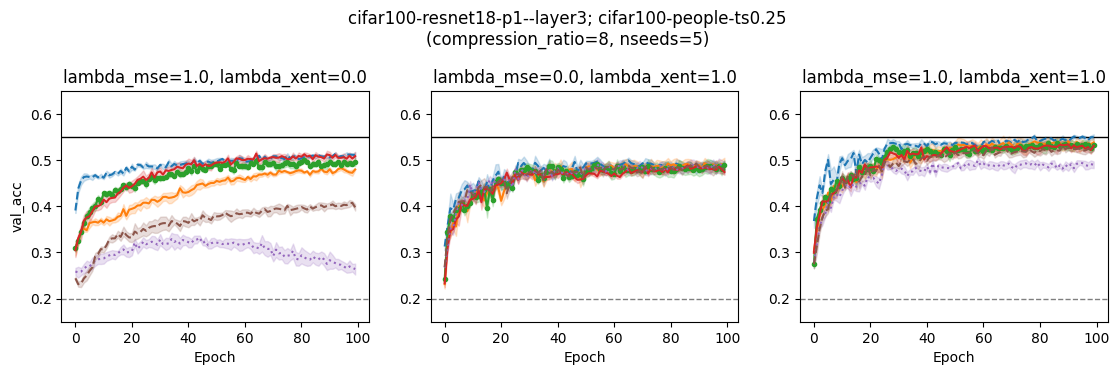

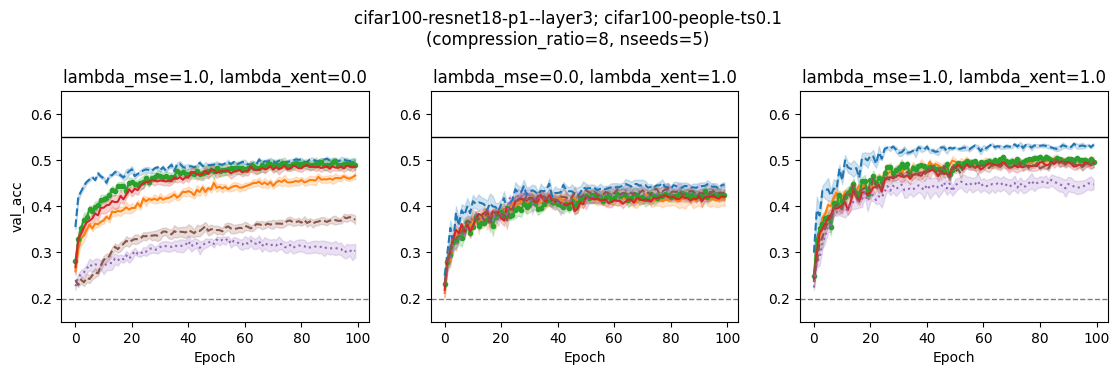

In [13]:
for ix, training_size in enumerate([1.0, 0.25, 0.1]):
    viz(
        df_people_cifar100,
        training_size=training_size, 
        compression_ratio=8,
        teacher_model="cifar100-resnet18-p1",
        layer="layer3",
        dataset="cifar100-people",
        show_legend=ix==0
    )

# Summary (to be confirmed)

Aims:
1. Verify that distilation can achieve good performance (as in the accuracy basis curve)
2. Influence of `MSE` and `Xent` terms on distillation.


Conclusions
1. Yes, the training configuration leads to expected performance. 
2. In small training size, using only MSE performs better than using Xent alone. Using the two objectves together leads to slightly better overall results.